# Стресс-тестирование риск-доходности продуктовой структуры розничного кредитного портфеля

### Сценарная модель границы экономически оправданного риска

Исследование оценивает, как структура синтетического розничного кредитного портфеля влияет на финансовый результат и устойчивость к стрессу. Портфель включает ипотеку, потребительские кредиты, автокредиты и кредитные карты и откалиброван на публичных данных ВТБ и Банка России.

> **Цель исследования — определить количественную границу, после которой дополнительная доходность более рискованной продуктовой структуры перестаёт компенсировать рост кредитных потерь.**

## Исследовательский вопрос

**При какой доле более рискованных продуктов прирост доходности перестаёт компенсировать рост кредитных потерь и снижение стрессовой устойчивости портфеля?**

Рабочая гипотеза состоит в том, что повышение доли высокодоходных продуктов улучшает результат лишь до некоторой границы, причём в стрессовом сценарии эта граница должна снижаться.

Проверка гипотезы строится не на прогнозной регрессии, а на прозрачном сочетании сценарного анализа, чувствительности и reverse stress.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "config" / "model_config.json").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import stress_model as sm

plt.style.use("seaborn-v0_8-whitegrid")
cfg = sm.load_config(ROOT / "config" / "model_config.json")
data = sm.load_dataset(ROOT / cfg.input_file, cfg.data_sheet)
base = sm.baseline_table(data, cfg)
product_results, sigmas = sm.build_scenarios(data, cfg)
summary = sm.scenario_summary(product_results, cfg.horizon_years)
factor = sm.factor_sensitivity(product_results, cfg)
reverse = sm.reverse_stress(product_results, cfg)
mortgage_sensitivity = sm.mortgage_pricing_sensitivity(data, cfg)
colors = {"Mortgage": "#4C78A8", "Consumer": "#F58518", "Auto": "#54A24B", "Cards": "#E45756"}

## Дизайн исследования

**Публичные данные → синтетический baseline → финансовая формула → стресс-сценарии → sensitivity → reverse stress → управленческий вывод**

| Элемент | Роль в исследовании |
|---|---|
| Публичные раскрытия ВТБ | Якоря объёма, структуры и кредитного риска |
| Ставки Банка России | Внешние pricing и funding proxies |
| Синтетический портфель | Сопоставимая четырёхпродуктовая модель, а не реконструкция экономики ВТБ |
| Moderate / Severe / Structural | Прозрачные сценарные предпосылки |
| Credit cost, CRAS, RAFR | Расчётные показатели модели |

Базовая дата — **30.06.2026**, горизонт — **2026H2 (0,5 года)**. Общий объём равен сумме четырёх продуктовых exposures на базовую дату и сохраняется при структурных экспериментах.

## Модель финансового результата

Кредитный риск измеряется annualized flow proxy:

$$CreditCost_i=\frac{2\times ECL\ remeasurement_i}{(Exposure_{i,t-1}+Exposure_{i,t})/2}$$

Доходность после стоимости фондирования и кредитного риска:

$$CRAS_i=Pricing_i-Funding_i-CreditCost_i$$

Шестимесячный финансовый результат:

$$RAFR_{6M}=0.5\times\sum_i Exposure_i\times CRAS_i$$

RAFR является модельным pre-operating результатом. Он не включает комиссии, операционные расходы, налоги и стоимость капитала и не интерпретируется как прибыль, NIM или RAROC банка.

## Базовая структура портфеля

Baseline отражает синтетическое сочетание публичных exposure anchors и внешних рыночных ставок. Таблица показывает вклад каждого продукта в риск-доходность портфеля.

In [2]:
base_results = sm.calculate_product_results(base, cfg.horizon_years, "Base")
baseline_view = base_results[[
    "product", "exposure", "weight", "credit_cost", "product_rate",
    "funding_rate", "credit_risk_adjusted_spread", "risk_adjusted_financial_result_bn"
]].copy()
baseline_view.columns = ["Продукт", "Объём, млрд руб.", "Доля", "Credit cost", "Pricing", "Funding", "CRAS", "RAFR 6M, млрд руб."]
display(baseline_view.style.hide(axis="index").format({
    "Объём, млрд руб.": "{:,.1f}", "Доля": "{:.1%}", "Credit cost": "{:.2%}",
    "Pricing": "{:.2%}", "Funding": "{:.2%}", "CRAS": "{:.2%}",
    "RAFR 6M, млрд руб.": "{:,.1f}"
}))
portfolio_result = float(base_results.risk_adjusted_financial_result_bn.sum())
display(Markdown(
    f"**Размер портфеля:** {base.exposure.sum():,.1f} млрд руб.  "
    f"**Base CRAS:** {portfolio_result / base.exposure.sum() / cfg.horizon_years:.2%}.  "
    f"**Base RAFR за 6М:** {portfolio_result:,.1f} млрд руб."
))

Продукт,"Объём, млрд руб.",Доля,Credit cost,Pricing,Funding,CRAS,"RAFR 6M, млрд руб."
Auto,543.9,8.3%,4.35%,16.50%,10.90%,1.25%,3.4
Cards,223.4,3.4%,5.59%,31.20%,13.00%,12.61%,14.1
Consumer,"1,525.9",23.2%,4.25%,17.50%,10.90%,2.35%,17.9
Mortgage,"4,279.8",65.1%,0.68%,9.00%,10.90%,-2.58%,-55.2


**Размер портфеля:** 6,573.0 млрд руб.  **Base CRAS:** -0.60%.  **Base RAFR за 6М:** -19.8 млрд руб.

## Риск и доходность продуктов

Положение продукта относительно диагонали показывает, компенсирует ли его спред до кредитного риска текущий credit cost. Размер точки пропорционален exposure.

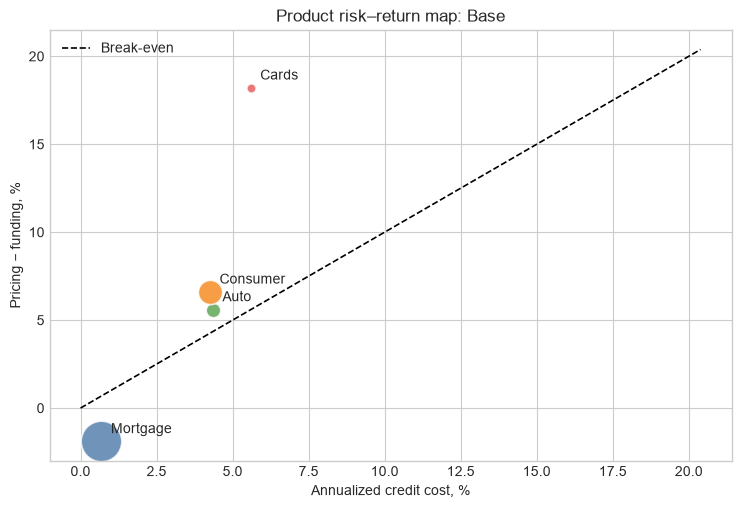

In [3]:
plot_base = base_results.copy()
plot_base["pre_risk_spread"] = plot_base.product_rate - plot_base.funding_rate
limit = max(plot_base.credit_cost.max(), plot_base.pre_risk_spread.max()) * 1.12

fig, ax = plt.subplots(figsize=(8.8, 5.6))
ax.plot([0, limit * 100], [0, limit * 100], linestyle="--", color="black", linewidth=1.2, label="Break-even")
for _, row in plot_base.iterrows():
    ax.scatter(row.credit_cost * 100, row.pre_risk_spread * 100,
               s=row.exposure / 5, color=colors[row['product']], alpha=0.8, edgecolor="white", linewidth=1.2)
    ax.annotate(row["product"], (row.credit_cost * 100, row.pre_risk_spread * 100),
                xytext=(7, 6), textcoords="offset points", fontsize=10)
ax.set_xlabel("Annualized credit cost, %")
ax.set_ylabel("Pricing − funding, %")
ax.set_title("Product risk–return map: Base")
ax.legend()
plt.show()

## Поведение портфеля в стресс-сценариях

- **Moderate:** умеренное ухудшение credit cost, pricing и funding.
- **Severe:** более сильное одновременное ухудшение финансовых факторов.
- **Structural:** перенос долей из Mortgage в Consumer, Auto и Cards при неизменном total.
- **Combined:** Severe и структурный сдвиг одновременно.

Коэффициенты Moderate и Severe являются сценарными параметрами, а не статистически оценённым прогнозом.

Сценарий,"Кредитные потери, млрд руб.",CRAS,"RAFR 6M, млрд руб."
Base,65.1,-0.60%,-19.8
Moderate,73.6,-2.15%,-70.6
Severe,82.1,-3.70%,-121.5
Structural,69.4,-0.39%,-12.8
Combined,93.6,-3.42%,-112.3


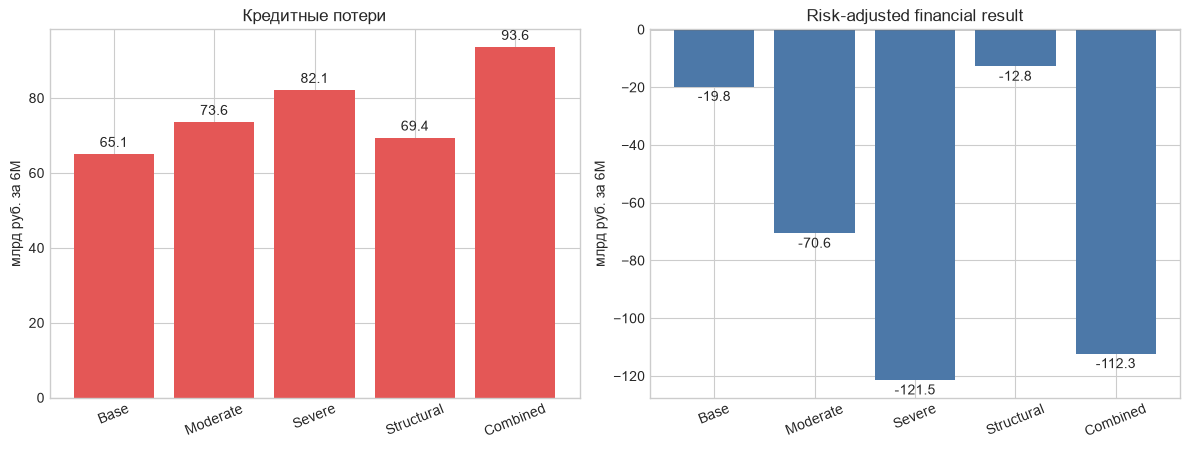

In [4]:
scenario_view = summary[["scenario", "credit_loss_bn", "credit_risk_adjusted_spread", "risk_adjusted_financial_result_bn"]].copy()
scenario_view.columns = ["Сценарий", "Кредитные потери, млрд руб.", "CRAS", "RAFR 6M, млрд руб."]
display(scenario_view.style.hide(axis="index").format({
    "Кредитные потери, млрд руб.": "{:,.1f}", "CRAS": "{:.2%}", "RAFR 6M, млрд руб.": "{:,.1f}"
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
bars_1 = axes[0].bar(summary.scenario, summary.credit_loss_bn, color="#E45756")
axes[0].bar_label(bars_1, fmt="%.1f", padding=3)
axes[0].set_title("Кредитные потери")
axes[0].set_ylabel("млрд руб. за 6М")
axes[0].tick_params(axis="x", rotation=22)

bars_2 = axes[1].bar(summary.scenario, summary.risk_adjusted_financial_result_bn, color="#4C78A8")
axes[1].bar_label(bars_2, fmt="%.1f", padding=3)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Risk-adjusted financial result")
axes[1].set_ylabel("млрд руб. за 6М")
axes[1].tick_params(axis="x", rotation=22)
fig.tight_layout()
plt.show()

## Как изменение структуры влияет на результат

Показатель ниже отвечает на прямой управленческий вопрос: как изменится шестимесячный результат, если 1 процентный пункт портфеля перенести из Mortgage в другой продукт при сохранении общего объёма.

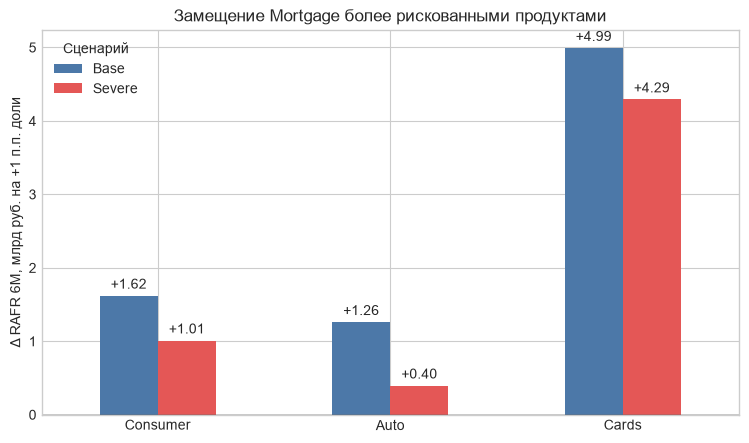

scenario,Base,Severe
product,,
Consumer,+1.62,+1.01
Auto,+1.26,+0.40
Cards,+4.99,+4.29


In [5]:
share_effect = factor[
    factor.factor.eq("share_plus_1pp_vs_mortgage") & factor.scenario.isin(["Base", "Severe"])
].pivot(index="product", columns="scenario", values="delta_result_bn").reindex(sm.RISKIER_PRODUCTS)

ax = share_effect.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Δ RAFR 6M, млрд руб. на +1 п.п. доли")
ax.set_title("Замещение Mortgage более рискованными продуктами")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Сценарий")
for container in ax.containers:
    ax.bar_label(container, fmt="%+.2f", padding=3)
plt.show()
display(share_effect.style.format("{:+.2f}"))

## Найдена ли критическая продуктовая доля?

При текущих proxies Consumer, Auto и Cards имеют более высокий CRAS, чем Mortgage, поэтому их увеличение **улучшает**, а не ухудшает модельный результат даже в Severe. Одновременно исходный RAFR уже находится ниже нулевой границы.

Следовательно, adverse critical share для этих продуктов в текущей калибровке не существует. Reverse-stress должен вернуть **NA**, а не искусственный процент.

Это не означает, что более рискованная структура всегда выгоднее. Результат показывает, что искомая граница не идентифицируется при текущем сочетании публичных income proxies и credit-cost inputs.

In [6]:
base_reverse = reverse[reverse.scenario.eq("Base")]
portfolio_threshold = base_reverse[base_reverse.reverse_type.eq("portfolio_credit_cost_multiplier")].iloc[0]
break_even = base_reverse[base_reverse.reverse_type.eq("product_break_even_credit_cost")].set_index("target_product")
share_rows = base_reverse[base_reverse.reverse_type.eq("critical_product_share_vs_mortgage")].set_index("target_product")

threshold_view = pd.DataFrame({
    "Показатель": [
        "Portfolio credit-cost multiplier до RAFR = 0",
        "Критическая доля Consumer", "Критическая доля Auto", "Критическая доля Cards",
        "Break-even credit cost: Consumer", "Break-even credit cost: Auto", "Break-even credit cost: Cards"
    ],
    "Значение": [
        f"{portfolio_threshold.threshold:.3f}x",
        "NA", "NA", "NA",
        f"{break_even.loc['Consumer', 'threshold']:.2%}",
        f"{break_even.loc['Auto', 'threshold']:.2%}",
        f"{break_even.loc['Cards', 'threshold']:.2%}"
    ],
    "Интерпретация": [
        "Нулевая граница достигается только при снижении текущего credit cost",
        share_rows.loc["Consumer", "status"], share_rows.loc["Auto", "status"], share_rows.loc["Cards", "status"],
        "Максимальный annualized credit cost при нулевом продуктовым CRAS",
        "Максимальный annualized credit cost при нулевом продуктовым CRAS",
        "Максимальный annualized credit cost при нулевом продуктовым CRAS"
    ]
})
display(threshold_view.style.hide(axis="index"))

Показатель,Значение,Интерпретация
Portfolio credit-cost multiplier до RAFR = 0,0.696x,Нулевая граница достигается только при снижении текущего credit cost
Критическая доля Consumer,NA,ALREADY_AT_OR_BELOW_BOUNDARY
Критическая доля Auto,NA,ALREADY_AT_OR_BELOW_BOUNDARY
Критическая доля Cards,NA,ALREADY_AT_OR_BELOW_BOUNDARY
Break-even credit cost: Consumer,6.60%,Максимальный annualized credit cost при нулевом продуктовым CRAS
Break-even credit cost: Auto,5.60%,Максимальный annualized credit cost при нулевом продуктовым CRAS
Break-even credit cost: Cards,18.20%,Максимальный annualized credit cost при нулевом продуктовым CRAS


## Ключевая чувствительность: ипотечная ставка

В Base используется mortgage proxy 9,0%. Рыночная ставка 17,8% рассматривается только как sensitivity endpoint и не является оценкой фактической доходности ипотечного портфеля ВТБ.

Цель теста — показать, насколько вывод о границе риска зависит от экономической сопоставимости доходной части модели.

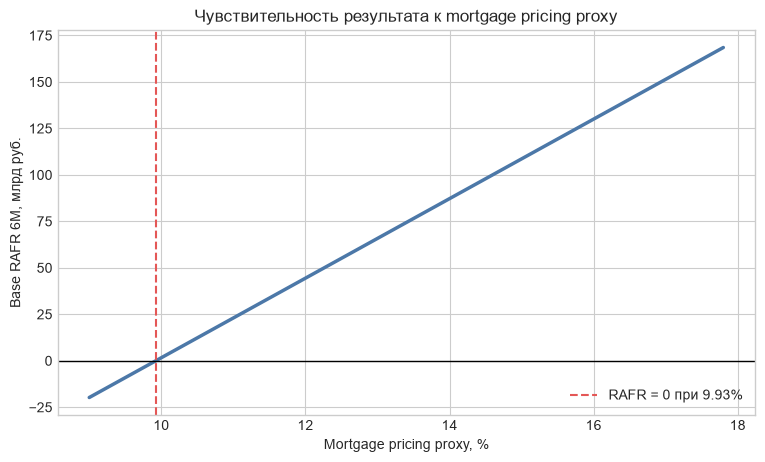

При неизменных остальных параметрах нулевая граница Base достигается при mortgage pricing около **9.93%**. На sensitivity endpoint 17,8% RAFR составляет **168.5 млрд руб.**

In [7]:
mortgage_row = base_results[base_results['product'].eq('Mortgage')].iloc[0]
critical_mortgage_rate = mortgage_row.product_rate + (cfg.critical_result_bn - portfolio_result) / (mortgage_row.exposure * cfg.horizon_years)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mortgage_sensitivity.mortgage_pricing_rate * 100,
        mortgage_sensitivity.risk_adjusted_financial_result_bn, color="#4C78A8", linewidth=2.5)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(critical_mortgage_rate * 100, color="#E45756", linestyle="--",
           label=f"RAFR = 0 при {critical_mortgage_rate:.2%}")
ax.set_xlabel("Mortgage pricing proxy, %")
ax.set_ylabel("Base RAFR 6M, млрд руб.")
ax.set_title("Чувствительность результата к mortgage pricing proxy")
ax.legend()
plt.show()
display(Markdown(
    f"При неизменных остальных параметрах нулевая граница Base достигается при mortgage pricing около "
    f"**{critical_mortgage_rate:.2%}**. На sensitivity endpoint 17,8% RAFR составляет "
    f"**{mortgage_sensitivity.iloc[-1].risk_adjusted_financial_result_bn:,.1f} млрд руб.**"
))

## Предварительные научные выводы

1. Структура портфеля существенно влияет на модельный финансовый результат: эффект 1 п.п. перераспределения различается по продуктам и сценариям.
2. Финансовый стресс последовательно повышает кредитные потери и снижает RAFR, однако точные уровни Moderate и Severe зависят от рабочих сценарных коэффициентов.
3. При текущей калибровке гипотеза об adverse critical share более рискованных продуктов **не подтверждается**: замещение Mortgage улучшает модельный результат, а исходный портфель уже находится ниже критической границы.
4. Главная причина неустойчивости вывода — mortgage pricing proxy. Его изменение способно поменять не только величину, но и знак портфельного результата и направление структурной sensitivity.
5. Поэтому итоговый порог экономически оправданного риска должен публиковаться только после проверки сопоставимости доходных proxies и устойчивости результата в альтернативных калибровках.

> **Текущий результат исследования — не готовая рекомендация по структуре портфеля ВТБ, а количественная диагностика условий, при которых такая рекомендация может считаться обоснованной.**